In [20]:
import anti_symmetric_dp
import pandas as pd
import numpy as np

In [ ]:
import os
import sys
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path
import matplotlib.patches as patches
import anti_symmetric_util as ay_util
import img2pdf

current_dir = Path.cwd()

# Parent directory
parent_dir = current_dir.parent

# Directories containing your modules
vis_dir = parent_dir / "vis"
connected_graphs_dir = parent_dir / "vis_connect"
long_dir = parent_dir / "long_peptide"

# Put them at the front of sys.path
sys.path.insert(0, str(vis_dir))
sys.path.insert(0, str(connected_graphs_dir))
sys.path.insert(0, str(long_dir))

import data_parse
import util
import peptide
import pandas as pd
import numpy as np
import connected_graph
from bisect import bisect_left



def format_path_string(path, with_aa= False):
    """
    Helper to turn a list of nodes [(0,0), (0,2)...] into the arrow string format
    Rounds numbers for cleaner display.
    """
    if not path: return ""
    
    def fmt_node(n):
        return f"({round(n[0], 3)}, {round(n[1], 3)})"
    
    output = fmt_node(path[0])
    
    for i in range(len(path) - 1):
        curr = path[i]
        next_n = path[i+1]
        
        # Determine direction
        # We use a small epsilon for direction check due to float precision,
        # though standard inequality usually works fine.
        if next_n[0] > curr[0]:
            direction = "Down ↓"
        else:
            direction = "Right →"
        if with_aa:
            if direction == "Down ↓":
                mass = round(next_n[0] - curr[0], 3)
            else:
                mass = round(next_n[1] - curr[1], 3)
            aa = None
            for key, value in amino_acid_masses.items():
                if abs(value - mass) <= 0.01:  # Allow small tolerance for matching
                    aa = key
                    break
            output += f" {direction}({aa}) {fmt_node(next_n)}"
        else:
        
            output += f" {direction} {fmt_node(next_n)}"
        
    return output


amino_acid_masses_merge = {
        "A": 71.03711,   # Alanine
        "R": 156.10111,  # Arginine
        "N": 114.04293,  # Asparagine
        "D": 115.02694,  # Aspartic acid
        "C": 103.00919,  # Cysteine
        "E": 129.04259,  # Glutamic acid
        "Q": 128.05858,  # Glutamine
        "G": 57.02146,   # Glycine
        "H": 137.05891,  # Histidine
        "J": 113.08406,  # Isoleucine
        #"L": 113.08406,  # Leucine
        "K": 128.09496,  # Lysine
        "M": 131.04049,  # Methionine
        "F": 147.06841,  # Phenylalanine
        "P": 97.05276,   # Proline
        "S": 87.03203,   # Serine
        "T": 101.04768,  # Threonine
        "W": 186.07931,  # Tryptophan
        "Y": 163.06333,  # Tyrosine
        "V": 99.06841    # Valine
    }

AA_MASSES = connected_graph.AA_MASSES
DOUBLE_AA_MASSES = connected_graph.DOUBLE_AA_MASSES
TRIPLE_AA_MASSES = connected_graph.TRIPLE_AA_MASSES
QUADRA_AA_MASSES = connected_graph.QUADRA_AA_MASSES


SOURCE_NODE = (0.0, 18.01056)
SINK_NODE = "Sink"

def construct_graph_nodes(spectrum):
    """
    Constructs the 2D grid nodes.
    Ensures the specific SOURCE_NODE (0, 18.01056) exists.
    """
    # 1. Ensure the specific coordinates for the source exist in the spectrum
    #    so the grid generation creates the node naturally.
    #    (Using a set to avoid duplicates)
    extended_spectrum = set(spectrum)
    extended_spectrum.add(SOURCE_NODE[0])
    extended_spectrum.add(SOURCE_NODE[1])
    sorted_spectrum = sorted(list(extended_spectrum))

    nodes = []
    
    # 2. Generate Grid
    for x1 in sorted_spectrum:
        for x2 in sorted_spectrum:
            # Rule: Remove diagonals (x1 == x2), unless it is the Source Node
            # (Note: (0, 18.01) is not diagonal, so it survives naturally, 
            #  but we keep the check just in case you revert to (0,0))
            if x1 != x2 or (x1 == SOURCE_NODE[0] and x2 == SOURCE_NODE[1]):
                nodes.append((x1, x2))
                
    return nodes

def build_adjacency_graph(nodes, allowed_masses, total_peptide_mass, threshold=0.01):
    """
    Constructs the graph edges, including Down, Right, and Sink connections.
    
    Args:
        nodes (list): List of (x1, x2) tuples.
        allowed_masses (list): List of valid mass gaps (AAs).
        total_peptide_mass (float): The total mass M of the peptide.
        threshold (float): Tolerance.
    """
    # Initialize graph
    graph = {node: [] for node in nodes}
    
    # Pre-processing for O(1) lookups
    valid_nodes_set = set(nodes)
    
    # Create a sorted lookup for allowed masses (for Sink check)
    sorted_allowed_masses = sorted(allowed_masses)
    
    # Create a sorted lookup for node coordinate existence (for Down/Right checks)
    # We combine all x1 and x2 values appearing in nodes to form the 'coordinate space'
    unique_coords = sorted(list(set([n[0] for n in nodes] + [n[1] for n in nodes])))

    def find_match_in_list(target, sorted_list):
        """Helper: Returns the matching value from a sorted list if within threshold."""
        idx = bisect_left(sorted_list, target)
        if idx < len(sorted_list) and abs(sorted_list[idx] - target) <= threshold:
            return sorted_list[idx]
        if idx > 0 and abs(sorted_list[idx - 1] - target) <= threshold:
            return sorted_list[idx - 1]
        return None

    for current_node in graph:
        x1, x2 = current_node
        max_current = max(x1, x2)
        
        # ---------------------------------------------------
        # 1. Check Sink Connection
        # Condition: TotalMass - x1 - x2 = Valid Mass
        # ---------------------------------------------------
        remainder = total_peptide_mass - x1 - x2
        
        # Only check if remainder is positive and physically possible
        if remainder > 0: 
            matched_mass = find_match_in_list(remainder, sorted_allowed_masses)
            if matched_mass is not None:
                # We found a bridge to the sink!
                # Edge Type: 'sink', Label: The mass that bridges the gap
                graph[current_node].append((SINK_NODE, matched_mass, 'sink'))

        # ---------------------------------------------------
        # 2. Check Standard Growth Edges (Down / Right)
        # ---------------------------------------------------
        for mass in allowed_masses:
            
            # --- DOWN Edge (x1 -> x1 + mass) ---
            target_x1 = find_match_in_list(x1 + mass, unique_coords)
            if target_x1 is not None:
                target_node = (target_x1, x2)
                if target_node in valid_nodes_set:
                    # Growth Condition
                    if max_current < max(target_x1, x2):
                        graph[current_node].append((target_node, mass, 'down'))

            # --- RIGHT Edge (x2 -> x2 + mass) ---
            target_x2 = find_match_in_list(x2 + mass, unique_coords)
            if target_x2 is not None:
                target_node = (x1, target_x2)
                if target_node in valid_nodes_set:
                    # Growth Condition
                    if max_current < max(x1, target_x2):
                        graph[current_node].append((target_node, mass, 'right'))

    return graph


def find_longest_path(graph, start_node, sink_node="Sink"):
    """
    Finds the longest path from start_node to sink_node in the DAG.
    
    Args:
        graph (dict): Adjacency dict {node: [(neighbor, mass, type), ...]}.
        start_node (tuple): The (0.0, 18.01...) source node.
        sink_node (str): The identifier for the sink.
        
    Returns:
        tuple: (max_length, path_of_masses, path_of_nodes)
               - max_length: Number of edges (amino acids).
               - path_of_masses: List of masses (e.g., [71.0, 57.0...]).
               - path_of_nodes: The sequence of graph nodes visited.
    """
    
    # Memoization table: stores result for nodes we've already solved
    # Format: { node: (length, [mass_sequence], [node_sequence]) }
    memo = {}

    def dfs(current_node):
        # 1. Base Case: Reached the Sink
        if current_node == sink_node:
            return (0, [], [sink_node])
        
        # 2. Check Memoization
        if current_node in memo:
            return memo[current_node]
        
        # 3. Recursive Step: Explore all neighbors
        best_length = -1
        best_mass_seq = []
        best_node_seq = []
        
        # If node has no outgoing edges (and isn't sink), it's a dead end.
        if current_node not in graph or not graph[current_node]:
            memo[current_node] = (-1, [], [])
            return (-1, [], [])

        for neighbor, mass, edge_type in graph[current_node]:
            # Recursively solve for the neighbor
            length, mass_seq, node_seq = dfs(neighbor)
            
            # If the neighbor leads to the sink (valid path found)
            if length != -1:
                # We add +1 for the current edge we are traversing
                current_length = 1 + length
                
                # Update if this path is longer than what we've found so far
                if current_length > best_length:
                    best_length = current_length
                    best_mass_seq = [mass] + mass_seq
                    best_node_seq = [current_node] + node_seq
        
        # 4. Store result and return
        if best_length != -1:
            memo[current_node] = (best_length, best_mass_seq, best_node_seq)
        else:
            # Mark as dead end if no neighbors lead to sink
            memo[current_node] = (-1, [], [])
            
        return memo[current_node]

    # Start the search
    return dfs(start_node)









In [65]:
# ─── Light Scientific Palette ────────────────────────────────────────────────
_PALETTE = {
    # Background & structure
    "bg":             "#FFFFFF",
    "grid_clean":     "#E8EAF0",
    "grid_spurious":  "#F5DADA",
    "tick_clean":     "#4A5068",
    "tick_spurious":  "#C03030",

    # Nodes
    "node_clean":     "#B0BED8",
    "node_spurious":  "#E8BFBF",

    # Correct path (hero)
    "hero_line":      "#00946B",
    "hero_glow":      "#00C88E",
    "hero_marker":    "#FFFFFF",
    "hero_box_bg":    "#E6F7F1",
    "hero_box_ec":    "#00946B",
    "hero_text":      "#006648",

    # Candidate paths
    "cand_line":      "#6C5FD0",
    "cand_marker":    "#FFFFFF",
    "cand_box_bg":    "#EEEAFC",
    "cand_box_ec":    "#6C5FD0",
    "cand_text":      "#4A3FA0",

    # Start / End markers
    "start_fill":     "#E83050",
    "start_edge":     "#B02040",
    "end_fill":       "#F0A010",
    "end_edge":       "#C08000",

    # Residual box
    "res_box_bg":     "#FFF8E8",
    "res_box_ec":     "#E09000",
    "res_text":       "#8B5E00",

    # Accents
    "title":          "#1A1E2E",
    "label":          "#5A6078",
    "legend_bg":      "#F6F7FA",
    "legend_ec":      "#D0D4E0",
    "legend_text":    "#3A4060",
    "spine":          "#C8CCD8",
}


def _stagger_tick_labels(ax, axis='x', min_gap_pt=10):
    """
    Detect overlapping tick labels, hide the originals, and replace them
    with annotated labels connected by thin leader lines back to the
    actual tick position on the axis.

    This completely eliminates overlap by placing shifted labels at
    guaranteed-clear positions with visible connection lines.

    min_gap_pt: minimum gap in points between label bounding boxes
                before staggering kicks in.
    """
    fig = ax.get_figure()
    renderer = fig.canvas.get_renderer()

    if axis == 'x':
        tick_objs = ax.xaxis.get_major_ticks()
        labels = [t.label2 for t in tick_objs]  # label2 = top
    else:
        tick_objs = ax.yaxis.get_major_ticks()
        labels = [t.label1 for t in tick_objs]  # label1 = left

    tick_positions = [t.get_loc() for t in tick_objs]

    # Get bounding boxes in display coords
    bboxes = []
    for lbl in labels:
        if lbl.get_text():
            try:
                bb = lbl.get_window_extent(renderer)
                bboxes.append(bb)
            except Exception:
                bboxes.append(None)
        else:
            bboxes.append(None)

    n = len(bboxes)
    if n < 2:
        return

    # Find crowded clusters
    overlaps_prev = [False] * n
    for i in range(1, n):
        if bboxes[i] is None or bboxes[i - 1] is None:
            continue
        prev, curr = bboxes[i - 1], bboxes[i]
        if axis == 'x':
            gap = curr.x0 - prev.x1
        else:
            gap = prev.y0 - curr.y1
        if gap < min_gap_pt:
            overlaps_prev[i] = True

    # Assign tier levels within each crowded run
    tier = [0] * n
    in_run = False
    run_counter = 0
    for i in range(n):
        if overlaps_prev[i]:
            if not in_run:
                in_run = True
                run_counter = 1
            else:
                run_counter += 1
            tier[i] = run_counter
        else:
            in_run = False
            run_counter = 0
            tier[i] = 0

    # ── Leader line style ──
    leader_style = dict(
        arrowstyle='-',
        color='#9098B0',
        lw=0.8,
        shrinkA=0,
        shrinkB=1,
    )

    # ── Offset magnitudes per tier level ──
    # Direction is computed contextually below: each shifted label moves
    # AWAY from the cluster's anchor (tier-0) label, so the leader line
    # never crosses over another label.
    if axis == 'x':
        # (|dx|, dy) — horizontal magnitude + vertical lift per level
        tier_magnitudes = [
            (0, 0),
            (18, 18),      # level 1
            (30, 32),      # level 2
            (42, 46),      # level 3
            (54, 60),      # level 4
        ]
    else:
        # (dx, |dy|) — leftward push + vertical magnitude per level
        tier_magnitudes = [
            (0, 0),
            (-22, 10),     # level 1
            (-22, 20),     # level 2
            (-38, 10),     # level 3
            (-38, 20),     # level 4
        ]

    # Find the anchor (tier-0) index for each shifted label's cluster
    # Walk backwards from each shifted label to find the first non-shifted one
    cluster_anchor_idx = [None] * n
    for i in range(n):
        if tier[i] > 0:
            # Walk backward to find the tier-0 anchor
            j = i - 1
            while j >= 0 and tier[j] > 0:
                j -= 1
            cluster_anchor_idx[i] = max(j, 0)

    for i in range(n):
        t = tier[i]
        if t == 0 or bboxes[i] is None:
            continue

        level = ((t - 1) % (len(tier_magnitudes) - 1)) + 1
        mag_a, mag_b = tier_magnitudes[level]

        # Determine direction: shift AWAY from the cluster anchor
        anchor_i = cluster_anchor_idx[i]
        anchor_pos = tick_positions[anchor_i] if anchor_i is not None else tick_positions[0]

        if axis == 'x':
            # If this tick is to the right of the anchor, shift right; else left
            if tick_positions[i] >= anchor_pos:
                dx_pt = mag_a   # shift right
            else:
                dx_pt = -mag_a  # shift left
            dy_pt = mag_b       # always lift up
        else:
            dx_pt = mag_a       # always shift left (negative value)
            # If this tick is below the anchor (larger y in inverted axis),
            # shift down; else up
            if tick_positions[i] >= anchor_pos:
                dy_pt = -mag_b  # shift down (positive y = lower on inverted)
            else:
                dy_pt = mag_b   # shift up

        # Get label properties before hiding
        text = labels[i].get_text()
        color = labels[i].get_color()
        fontweight = labels[i].get_fontweight()
        fontsize = labels[i].get_fontsize() - min(0.8, level * 0.3)
        pos = tick_positions[i]

        # Hide the original label
        labels[i].set_visible(False)

        # Place annotation with leader line using blended transform:
        # The anchor point (xy) is at the tick position on the axis edge.
        # For x-axis top: (data_x, axes_y=1.0) — top edge
        # For y-axis left: (axes_x=0.0, data_y) — left edge
        if axis == 'x':
            xy_point = (pos, 1.0)
            xy_transform = ax.get_xaxis_transform()  # x=data, y=axes
            ha, va = 'center', 'bottom'
            rotation = 90
        else:
            xy_point = (0.0, pos)
            xy_transform = ax.get_yaxis_transform()  # x=axes, y=data
            ha, va = 'right', 'center'
            rotation = 0

        # Place the annotation with leader line
        ax.annotate(
            text,
            xy=xy_point,
            xycoords=xy_transform,
            xytext=(dx_pt, dy_pt),
            textcoords='offset points',
            fontsize=fontsize,
            fontfamily='monospace',
            fontweight=fontweight,
            color=color,
            ha=ha, va=va,
            rotation=rotation,
            arrowprops=leader_style,
            zorder=100,
            annotation_clip=False,
        )


def visualize_all_paths(spectrum, spurious_masses=None,
                        candidate_paths=None, correct_path=None,
                        tolerance=0.02, aa_map=None, pep_mass=None,
                        title="Peptide Spectrum Graph",
                        save_path=None, figsize=(18, 18), dpi=300):
    """
    Modern visualization of peptide spectrum graph paths.

    Light scientific theme with subtle glow effects for hero paths,
    refined typography, and smart tick-label de-overlapping.

    Args:
        spectrum: List of fragment masses.
        spurious_masses: Optional set/list of masses considered spurious.
        candidate_paths: List of candidate paths, each a list of (x1, x2) tuples.
        correct_path: The correct path as a list of (x1, x2) tuples.
        tolerance: Mass tolerance for snapping and AA matching.
        aa_map: Dict mapping {mass: aa_name} for edge annotation.
        pep_mass: Total peptide mass for residual calculation at endpoints.
        title: Plot title string.
        save_path: If provided, saves figure to this path instead of showing.
        figsize: Figure dimensions.
        dpi: Resolution for saved figures.
    """
    P = _PALETTE

    # ── 1. Setup & Classification ──────────────────────────────────────────
    S = sorted(list(set(spectrum)))
    S_arr = np.array(S)

    spurious_set = set(spurious_masses) if spurious_masses else set()
    is_spurious = lambda val: val in spurious_set

    # ── 2. Create Figure ───────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=figsize, facecolor=P["bg"])
    ax.set_facecolor(P["bg"])

    # ── 3. Grid ────────────────────────────────────────────────────────────
    for mass in S:
        if is_spurious(mass):
            c, a, ls, lw = P["grid_spurious"], 0.5, (0, (4, 4)), 0.5
        else:
            c, a, ls, lw = P["grid_clean"], 0.6, (0, (1, 3)), 0.4
        ax.axvline(x=mass, color=c, linestyle=ls, linewidth=lw, alpha=a)
        ax.axhline(y=mass, color=c, linestyle=ls, linewidth=lw, alpha=a)

    # ── 4. Nodes ───────────────────────────────────────────────────────────
    X, Y = np.meshgrid(S, S)
    is_noise_mask = np.array([is_spurious(m) for m in S])
    X_noise, Y_noise = np.meshgrid(is_noise_mask, is_noise_mask)
    node_is_noise = X_noise | Y_noise

    ax.scatter(X[node_is_noise], Y[node_is_noise],
               s=10, c=P["node_spurious"], alpha=0.4, zorder=1,
               edgecolors='none')
    ax.scatter(X[~node_is_noise], Y[~node_is_noise],
               s=14, c=P["node_clean"], alpha=0.5, zorder=2,
               edgecolors='none')

    # ── 5. Helpers ─────────────────────────────────────────────────────────
    def get_closest_in_spectrum(val):
        idx = (np.abs(S_arr - val)).argmin()
        closest = S_arr[idx]
        return closest if abs(closest - val) <= tolerance else val

    def get_snapped_path(raw_path):
        return [(get_closest_in_spectrum(px), get_closest_in_spectrum(py))
                for px, py in raw_path]

    def get_anno_text(mass_diff):
        abs_diff = abs(mass_diff)
        txt = f"{mass_diff:.2f}"
        if aa_map:
            min_diff = tolerance + 1e-9
            best_name = None
            for aa_mass, name in aa_map.items():
                diff = abs(abs_diff - aa_mass)
                if diff <= tolerance and diff < min_diff:
                    min_diff = diff
                    best_name = name
            if best_name:
                txt = f"{best_name}\n({mass_diff:.2f})"
        return txt

    # ── 6. Path Drawing ───────────────────────────────────────────────────
    def draw_path(path_data, is_hero=False):
        if not path_data or len(path_data) < 2:
            return

        snapped = get_snapped_path(path_data)

        if is_hero:
            line_c   = P["hero_line"]
            marker_c = P["hero_marker"]
            box_bg   = P["hero_box_bg"]
            box_ec   = P["hero_box_ec"]
            text_c   = P["hero_text"]
            lw, alpha, ls = 2.8, 0.95, '-'
            ms, fs = 7, 8.5
            z = 50
        else:
            line_c   = P["cand_line"]
            marker_c = P["cand_marker"]
            box_bg   = P["cand_box_bg"]
            box_ec   = P["cand_box_ec"]
            text_c   = P["cand_text"]
            lw, alpha, ls = 1.4, 0.65, (0, (5, 3))
            ms, fs = 5, 7
            z = 20

        # Subtle glow / shadow effect for hero path
        if is_hero:
            for glow_lw, glow_a in [(9, 0.05), (6, 0.08), (4, 0.12)]:
                for i in range(len(snapped) - 1):
                    p0, p1 = snapped[i], snapped[i + 1]
                    ax.plot([p0[0], p1[0]], [p0[1], p1[1]],
                            color=P["hero_glow"], linewidth=glow_lw,
                            alpha=glow_a, solid_capstyle='round', zorder=z - 1)

        # Start node
        start = snapped[0]
        s_size = 220 if is_hero else 80
        ax.scatter([start[0]], [start[1]],
                   color=P["start_fill"], s=s_size,
                   edgecolors=P["start_edge"], linewidth=1.2,
                   zorder=z + 5, alpha=0.9)
        if is_hero:
            ax.scatter([start[0]], [start[1]],
                       color=P["start_fill"], s=s_size * 3,
                       edgecolors='none', alpha=0.06, zorder=z + 4)

        # Edges
        for i in range(len(snapped) - 1):
            p0 = snapped[i]
            p1 = snapped[i + 1]

            ax.plot([p0[0], p1[0]], [p0[1], p1[1]],
                    color=line_c, linewidth=lw, alpha=alpha, linestyle=ls,
                    marker='o', markersize=ms,
                    markerfacecolor=marker_c, markeredgecolor=line_c,
                    markeredgewidth=1.2, solid_capstyle='round',
                    zorder=z)

            dx, dy = p1[0] - p0[0], p1[1] - p0[1]
            mass_jump = max(abs(dx), abs(dy))
            mid_x = (p0[0] + p1[0]) / 2
            mid_y = (p0[1] + p1[1]) / 2

            ax.text(mid_x, mid_y, get_anno_text(mass_jump),
                    ha='center', va='center', fontsize=fs,
                    color=text_c, fontweight='semibold',
                    fontfamily='monospace',
                    bbox=dict(boxstyle='round,pad=0.25',
                              fc=box_bg, ec=box_ec, alpha=0.92, lw=0.8),
                    zorder=z + 10)

        # End node (star)
        end = snapped[-1]
        e_size = 350 if is_hero else 120
        ax.scatter([end[0]], [end[1]],
                   color=P["end_fill"], marker='*', s=e_size,
                   edgecolors=P["end_edge"], linewidth=0.8,
                   zorder=z + 15, alpha=0.9)
        if is_hero:
            ax.scatter([end[0]], [end[1]],
                       color=P["end_fill"], s=e_size * 2.5,
                       edgecolors='none', alpha=0.06, zorder=z + 14)

        # Residual annotation
        if pep_mass is not None:
            residual = pep_mass - (end[0] + end[1])
            res_text = get_anno_text(residual)
            label = f"Δ {res_text}"

            ax.text(end[0], end[1], label,
                    ha='center', va='bottom', fontsize=fs,
                    color=P["res_text"], fontweight='semibold',
                    fontfamily='monospace',
                    bbox=dict(boxstyle='round,pad=0.3',
                              fc=P["res_box_bg"], ec=P["res_box_ec"],
                              alpha=0.95, lw=1.0),
                    zorder=z + 20)

    # ── 7. Draw Paths ─────────────────────────────────────────────────────
    if candidate_paths:
        for path in candidate_paths:
            draw_path(path, is_hero=False)

    if correct_path:
        draw_path(correct_path, is_hero=True)

    # ── 8. Axis Formatting ────────────────────────────────────────────────
    ax.set_xticks(S)
    ax.set_yticks(S)
    ax.set_xticklabels([f"{v:.2f}" for v in S], rotation=90, fontsize=8,
                        fontfamily='monospace')
    ax.set_yticklabels([f"{v:.2f}" for v in S], fontsize=8,
                        fontfamily='monospace')
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')

    # Color tick labels
    for tick, val in zip(ax.xaxis.get_major_ticks(), S):
        lbl = tick.label2
        if is_spurious(val):
            lbl.set_color(P["tick_spurious"])
            lbl.set_fontweight('bold')
        else:
            lbl.set_color(P["tick_clean"])

    for tick, val in zip(ax.yaxis.get_major_ticks(), S):
        lbl = tick.label1
        if is_spurious(val):
            lbl.set_color(P["tick_spurious"])
            lbl.set_fontweight('bold')
        else:
            lbl.set_color(P["tick_clean"])

    # Tick & spine styling
    ax.tick_params(axis='both', which='both',
                   color=P["spine"], length=4, width=0.5)
    for spine in ax.spines.values():
        spine.set_color(P["spine"])
        spine.set_linewidth(0.6)

    pad = 5
    ax.set_xlim(min(S) - pad, max(S) + pad)
    ax.set_ylim(min(S) - pad, max(S) + pad)
    ax.invert_yaxis()

    ax.set_xlabel("Fragment mass x₁ (Da)", labelpad=14,
                  fontsize=11, color=P["label"], fontfamily='sans-serif')
    ax.set_ylabel("Fragment mass x₂ (Da)", labelpad=10,
                  fontsize=11, color=P["label"], fontfamily='sans-serif')

    # ── 9. Legend ──────────────────────────────────────────────────────────
    legend_elements = [
        Line2D([0], [0], color=P["hero_line"], lw=2.8,
               label='Correct path'),
        Line2D([0], [0], color=P["cand_line"], lw=1.4,
               linestyle='--', label='Candidate path'),
        Line2D([0], [0], marker='o', color='none',
               markerfacecolor=P["start_fill"], markeredgecolor=P["start_edge"],
               markersize=8, label='Start node'),
        Line2D([0], [0], marker='*', color='none',
               markerfacecolor=P["end_fill"], markeredgecolor=P["end_edge"],
               markersize=10, label='End node (+ residual)'),
        Line2D([0], [0], marker='s', color='none',
               markerfacecolor=P["node_spurious"], markersize=7,
               alpha=0.6, label='Spurious node'),
    ]

    leg = ax.legend(handles=legend_elements,
                    loc='upper right', bbox_to_anchor=(1.0, 1.0),
                    fontsize=9, frameon=True,
                    facecolor=P["legend_bg"], edgecolor=P["legend_ec"],
                    labelcolor=P["legend_text"],
                    borderpad=1.0, handletextpad=0.8)
    leg.get_frame().set_alpha(0.95)
    leg.get_frame().set_linewidth(0.6)

    # ── 10. Title ─────────────────────────────────────────────────────────
    ax.set_title(title, pad=36, fontsize=15, fontweight='semibold',
                 color=P["title"], fontfamily='sans-serif',
                 loc='left')

    ax.text(1.0, 1.02, "2D-PC-MS",
            transform=ax.transAxes, ha='right', va='bottom',
            fontsize=9, color=P["label"], alpha=0.35,
            fontfamily='monospace', fontweight='light')

    # ── 11. De-overlap tick labels ────────────────────────────────────────
    # Must draw canvas first so label bounding boxes are computed
    fig.canvas.draw()
    _stagger_tick_labels(ax, axis='x', min_gap_pt=6)
    _stagger_tick_labels(ax, axis='y', min_gap_pt=8)

    # ── 12. Save / Show ───────────────────────────────────────────────────
    if save_path:
        directory = os.path.dirname(save_path)
        if directory and not os.path.exists(directory):
            os.makedirs(directory)
        plt.savefig(save_path, bbox_inches='tight', dpi=dpi,
                    facecolor=fig.get_facecolor(), edgecolor='none')
        plt.close(fig)
        print(f"Saved → {save_path}")
    else:
        plt.tight_layout()
        plt.show()


9
[(0.0, 18.01056), (299.15536, 18.01056), (299.15536, 400.28704), (414.18229999999994, 400.28704), (414.18229999999994, 499.35544999999996), (527.26636, 499.35544999999996), (598.30347, 499.35544999999996), (598.30347, 628.39804), (598.30347, 756.45662), 'Sink']


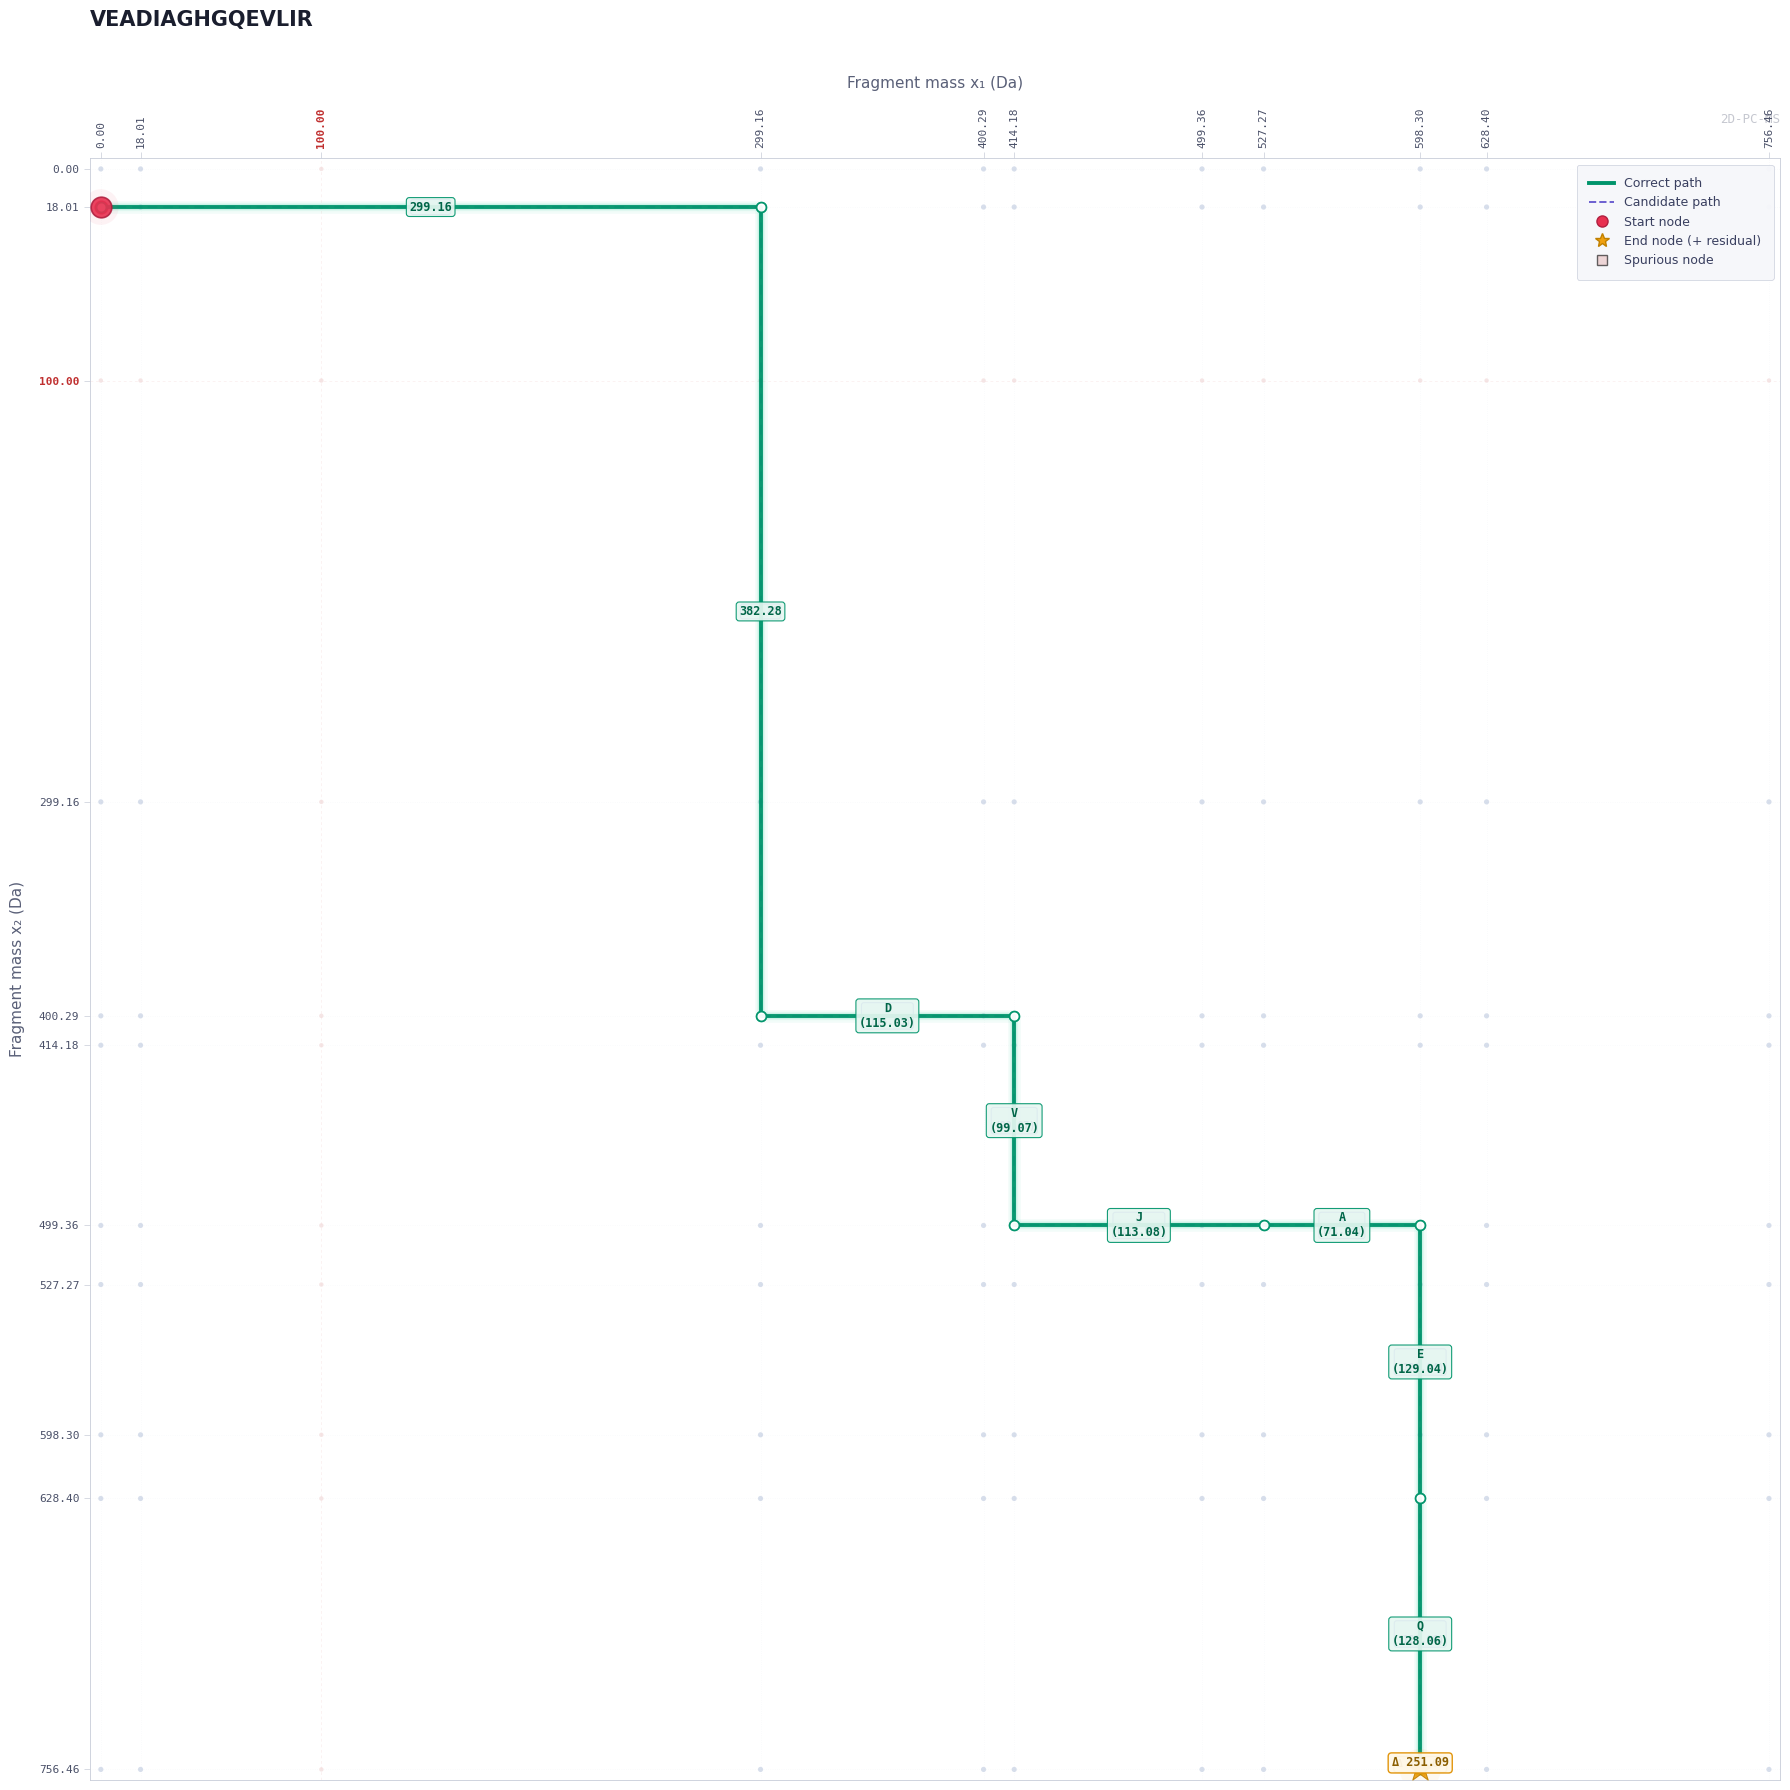

In [62]:
if __name__ =='__main__':
    
    allowed_mass_list = list(AA_MASSES.values()) + list(DOUBLE_AA_MASSES.values()) + list(TRIPLE_AA_MASSES.values()) + list(QUADRA_AA_MASSES.values())
    
    #pep_seq = 'HADGSFSDEMNTILDNLAARDFINWLIQTKITD'
    pep_seq = 'VEADIAGHGQEVLIR'
    charge = 3

    pep = peptide.Pep(f'[{pep_seq}+{charge}H]{charge}+', end_h20=True)
    #breaks = [i for i in range(1, len(pep_seq))]
    #breaks = [2, 7, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]
    breaks = [3, 4, 5, 6, 8, 9, 10, 11, 12]

    spec = [pep.ion_mass(f'b{i}') for i in breaks] + [pep.ion_mass(f'y{len(pep_seq) - i}') for i in breaks]
    spec = [i-1 for i in spec]
    spec = [0] + [18.01056] + spec + [pep.pep_mass] + [100]
    spec.sort()
    sorted_array = spec
    mid_point = len(sorted_array) // 2
    lower_half = sorted_array[:mid_point]
    upper_half = sorted_array[mid_point:]
    lower_half.sort()
    graph = construct_graph_nodes(lower_half)
    graph = build_adjacency_graph(nodes = graph, allowed_masses=allowed_mass_list, total_peptide_mass=pep.pep_mass - charge*1.007276, threshold=0.05)
    length, peptide_masses, node_path = find_longest_path(graph=graph, start_node=SOURCE_NODE)
    print(length)
    print(node_path)
    
    correct = node_path[:-1]
    candidates = [correct]
    
    amino_acid_masses_switch = {v: k for k, v in amino_acid_masses_merge.items()}
    
    visualize_all_paths(lower_half, spurious_masses=[100], 
                         candidate_paths=candidates, 
                         correct_path=correct, 
                         aa_map=amino_acid_masses_switch,
                         title = pep_seq,
                         pep_mass=pep.seq_mass + 18.01056,
                         save_path= False)
    
    print()

In [26]:
import annot

df = pd.read_excel('/Users/kevinmbp/Desktop/2D_spec_dict/anti_symmetric/data/Covariance Scoring Tables 10000 Scans.xlsx', sheet_name='VEADIAGHGQEVLIR-mz536-3_cov')
df = df[['m/z fragment 1', 'm/z fragment 2', 'Covariance', 'Partial Cov.', 'Score', 'Ranking']]
df.columns = ['m/z A', 'm/z B', 'Covariance', 'Partial Cov.', 'Score', 'Ranking'] 
df = df[df['Score'] > 0]
data = df

data['Ranking'] = data['Ranking'].fillna(-1)
data['Ranking'] = data['Ranking'].astype(int)
data = data.sort_values('Ranking', ascending=True)
data = data[data['Ranking'] != -1]
head_num = 500
data = data.sort_values('Ranking', ascending = True)
data = data.head(head_num)
partitioned_data, partitioned_names = annot.partition_dataframe_by_charge(data, [charge, charge - 1])

In [27]:
iso = 1
loss_list = [100.068]
df_all = []
for i in loss_list:
    each_data = annot.select_best_partition(partitioned_data, ['m/z A', 'm/z B', 'Ranking'], pep.pep_mass - i, 0.1,partitioned_names, iso_range=0)
    #each_data = each_data.sort_values('Ranking', ascending=True)
    num_ffc = each_data.shape[0]
    
    each_data = annot.annotate_dataframe_loss(each_data, pep, 0.1, diffs=[i], charge=charge,iso_range=iso)
    each_data['line'] = 'parent' if i == 0 else -i
    each_data['num_ffc'] = num_ffc
    df_all.append(each_data)
df_all = pd.concat(df_all, ignore_index=True)
df_all = df_all.sort_values('Ranking', ascending = True)
df_all.head()

,m/z A,m/z B,Ranking,selected_total,component_x1,component_x2,charge_A,charge_B,adj_mass_A,adj_mass_B,...,theoretical_mass_A,iso_A,base_name_A,explanation_B,deviation_B,theoretical_mass_B,iso_B,base_name_B,line,num_ffc
10,814.482029,694.319024,23,1508.801053,814.482029,694.319024,1,1,814.482029,694.319024,...,814.47808,0,y7,(+1)-100.068,0.000166,694.31919,1,b8,-100.068,6
11,694.319024,814.482029,23,1508.801053,694.319024,814.482029,1,1,694.319024,814.482029,...,694.31919,1,b8,0,0.003949,814.47808,0,y7,-100.068,6
0,401.288604,1107.512648,29,1508.801252,401.288604,1107.512648,1,1,401.288604,1107.512648,...,401.28704,0,y3,0,0.006178,1107.50647,0,b11,-100.068,6
1,401.288604,1107.512648,29,1508.801252,401.288604,1107.512648,1,1,401.288604,1107.512648,...,401.28704,0,y3,(+1)-100.068,0.002418,1107.51023,1,b12,-100.068,6
2,401.288604,1107.512648,29,1508.801252,401.288604,1107.512648,1,1,401.288604,1107.512648,...,401.29080,1,y4,0,0.006178,1107.50647,0,b11,-100.068,6


In [28]:
breaks = [3, 4, 5, 6, 8, 9, 10, 11, 12]

b_ion = [pep.ion_mass(f'b{i}') for i in breaks]
b_ion = [i-1 for i in b_ion]
y_ion = [pep.ion_mass(f'y{len(pep_seq) - i}') for i in breaks]
y_ion = [i-1 for i in y_ion]

In [29]:
b_ion

[299.15536,
 414.18229999999994,
 527.26636,
 598.30347,
 792.38384,
 849.4053,
 977.46388,
 1106.50647,
 1205.5748800000001]

In [30]:
a1 = list(set(df_all['adj_mass_A']))
a2 = list(set(df_all['adj_mass_B']))

In [31]:
import internal
delta_val = 0.01
s, sim, virtuals = internal.find_optimal_shift_and_virtual_ions(a1, b_ion, delta=delta_val)

In [32]:
print(f"Optimal Shift (s): {s:.2f}")
print(f"SIM Score: {sim}")
print(f"Virtual Ions to add to Grandmaster Ladder: {virtuals}")

Optimal Shift (s): 98.06
SIM Score: 3
Virtual Ions to add to Grandmaster Ladder: [912.5383429999999, 1106.620215, 499.34491799999995]


In [33]:
iso = 1
loss_list = [229.111]
df_all = []
for i in loss_list:
    each_data = annot.select_best_partition(partitioned_data, ['m/z A', 'm/z B', 'Ranking'], pep.pep_mass - i, 0.1,partitioned_names, iso_range=0)
    #each_data = each_data.sort_values('Ranking', ascending=True)
    num_ffc = each_data.shape[0]
    
    each_data = annot.annotate_dataframe_loss(each_data, pep, 0.1, diffs=[i], charge=charge,iso_range=iso)
    each_data['line'] = 'parent' if i == 0 else -i
    each_data['num_ffc'] = num_ffc
    df_all.append(each_data)
df_all = pd.concat(df_all, ignore_index=True)
df_all = df_all.sort_values('Ranking', ascending = True)

a1 = list(set(df_all['adj_mass_A']))
a2 = list(set(df_all['adj_mass_B']))
s, sim, virtuals = internal.find_optimal_shift_and_virtual_ions(a1, y_ion, delta=delta_val)
print(f"Optimal Shift (s): {s:.2f}")
print(f"SIM Score: {sim}")
print(f"Virtual Ions to add to Grandmaster Ladder: {virtuals}")



Optimal Shift (s): -1.01
SIM Score: 6
Virtual Ions to add to Grandmaster Ladder: [287.192438, 1090.543166, 427.204033, 174.108041, 878.388184, 749.344953, 370.18224899999996, 1203.6274379999998, 564.263613, 621.285369, 977.457572, 950.530301]


15
[(0.0, 18.01056), (99.065, 18.01056), (99.065, 174.108041), (228.109, 174.108041), (228.109, 287.192438), (299.15536, 287.192438), (299.15536, 400.28704), (414.18229999999994, 400.28704), (414.18229999999994, 499.35544999999996), (527.26636, 499.35544999999996), (598.30347, 499.35544999999996), (598.30347, 628.39804), (598.30347, 756.45662), (598.30347, 813.4780800000001), (598.30347, 950.530301), 'Sink']


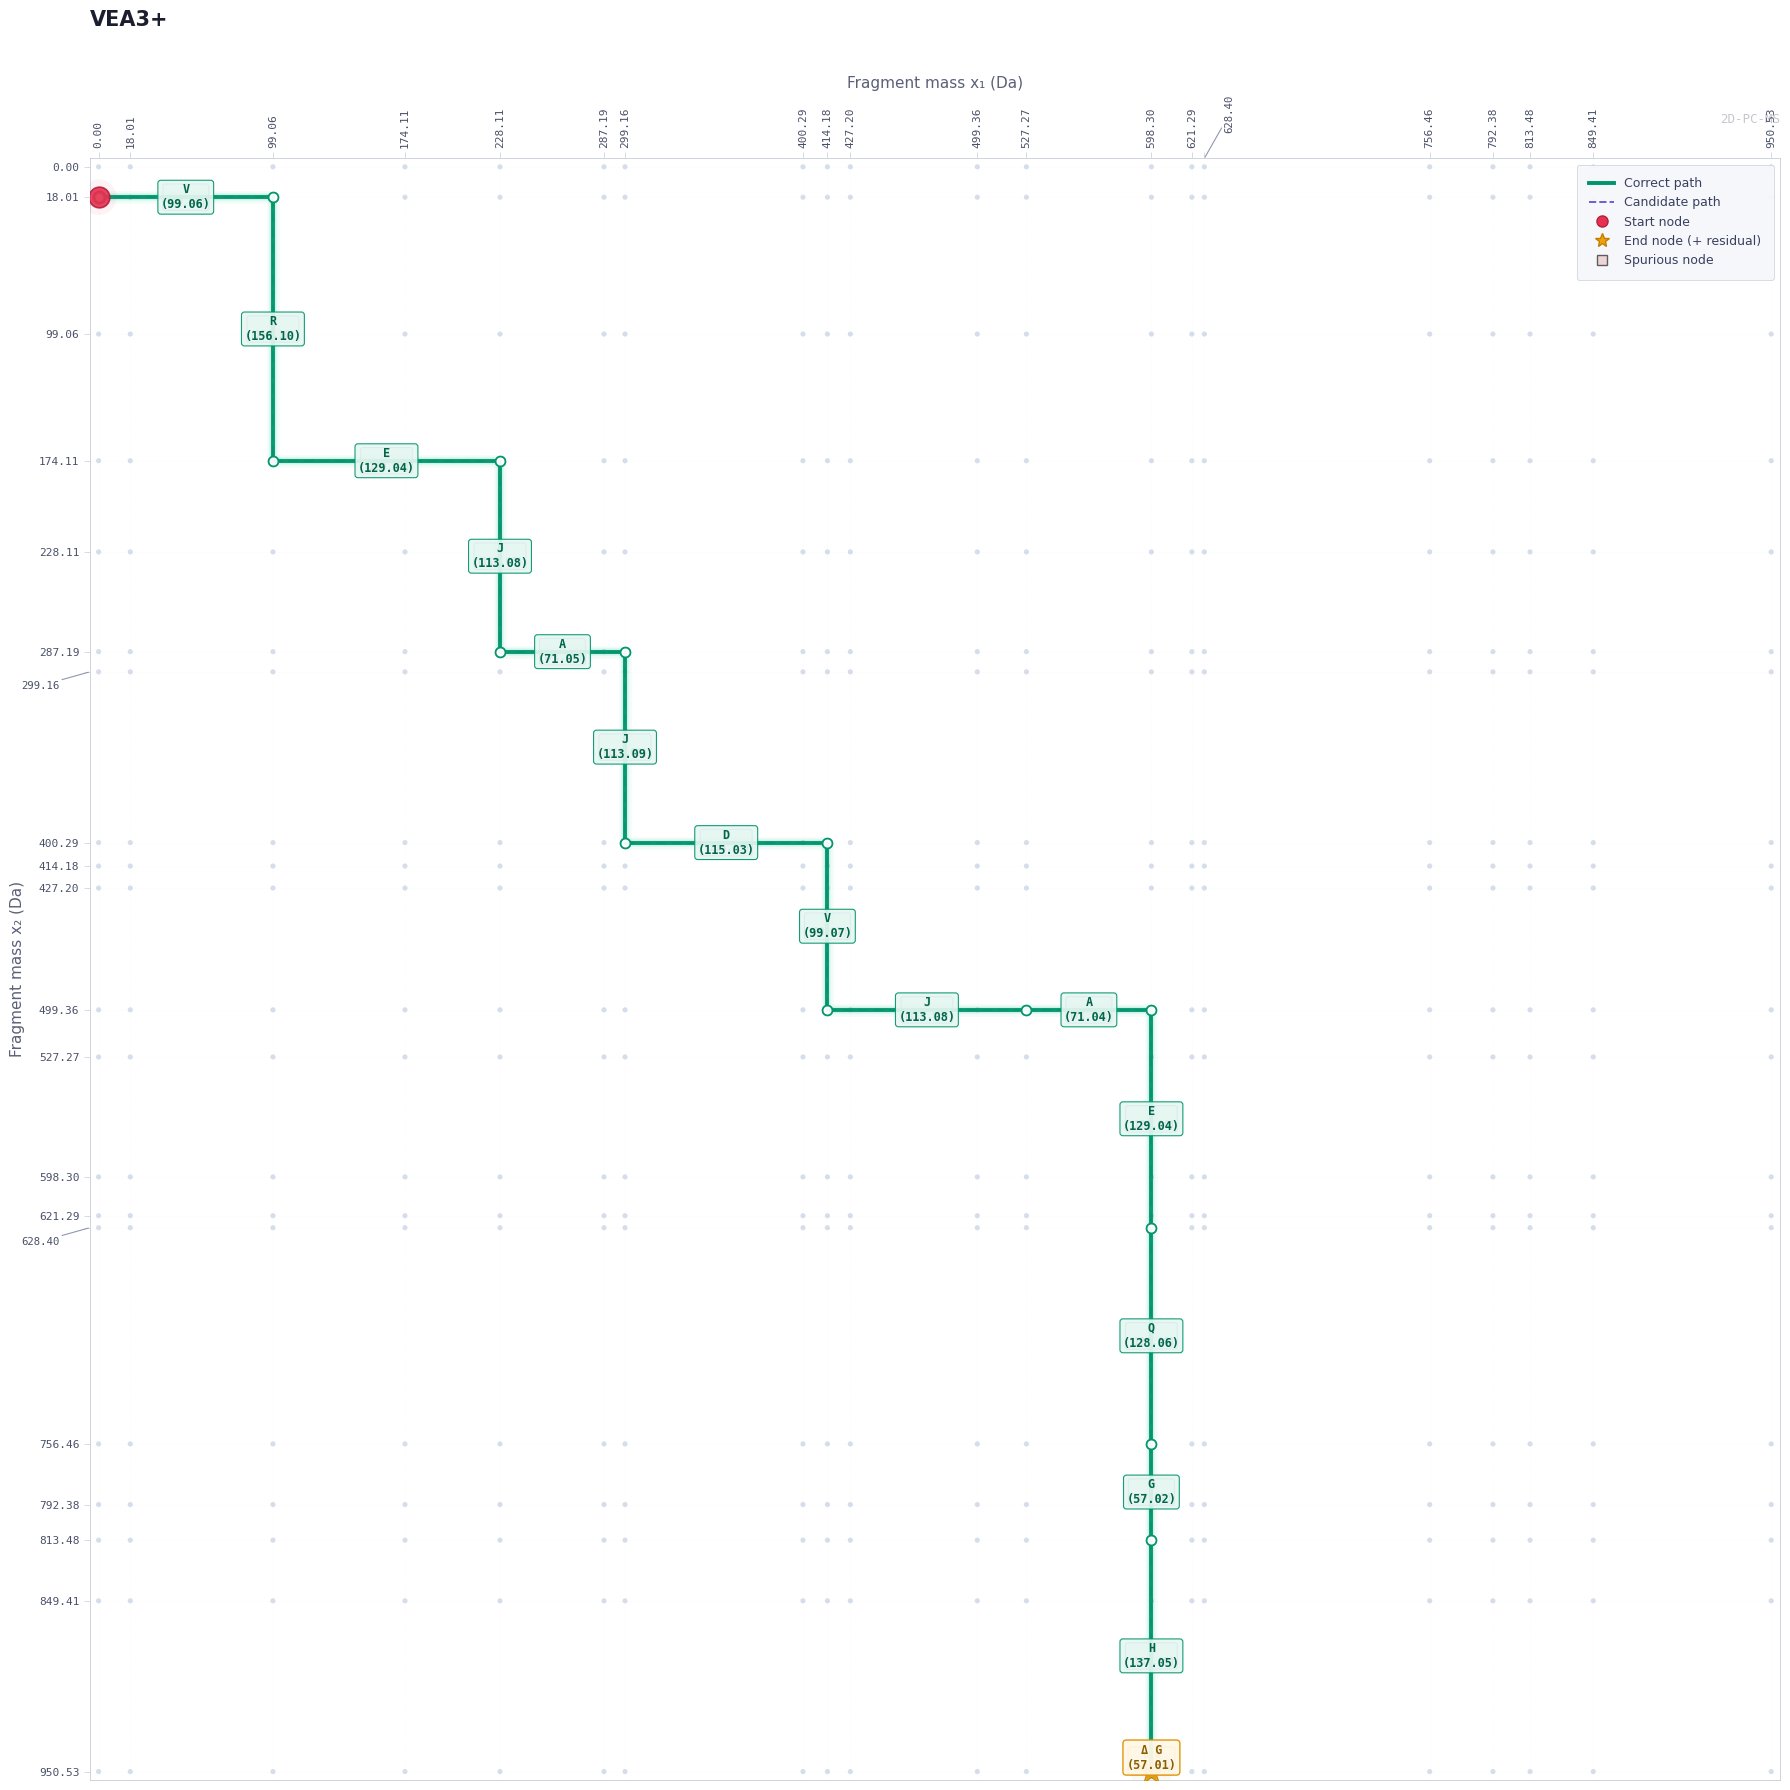

In [67]:
if __name__ =='__main__':
    
    allowed_mass_list = list(AA_MASSES.values()) + list(DOUBLE_AA_MASSES.values()) + list(TRIPLE_AA_MASSES.values()) + list(QUADRA_AA_MASSES.values())
    
    #pep_seq = 'HADGSFSDEMNTILDNLAARDFINWLIQTKITD'
    pep_seq = 'VEADIAGHGQEVLIR'
    charge = 3

    pep = peptide.Pep(f'[{pep_seq}+{charge}H]{charge}+', end_h20=True)
    #breaks = [i for i in range(1, len(pep_seq))]
    #breaks = [2, 7, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]
    breaks = [3, 4, 5, 6, 8, 9, 10, 11, 12]

    spec = [pep.ion_mass(f'b{i}') for i in breaks] + [pep.ion_mass(f'y{len(pep_seq) - i}') for i in breaks]
    spec = [i-1 for i in spec]
    spec = [0] + [18.01056] + spec + [pep.pep_mass] + [938.464043*3-1, 953.522196-1] + [287.192438, 1090.543166, 427.204033, 174.108041, 621.285369, 977.457572, 950.530301] + [99.065, 228.109]
    spec.sort()
    sorted_array = spec
    mid_point = len(sorted_array) // 2 + 4
    lower_half = sorted_array[:mid_point]
    upper_half = sorted_array[mid_point:]
    lower_half.sort()
    graph = construct_graph_nodes(lower_half)
    graph = build_adjacency_graph(nodes = graph, allowed_masses=allowed_mass_list, total_peptide_mass=pep.pep_mass - charge*1.007276, threshold=0.1)
    length, peptide_masses, node_path = find_longest_path(graph=graph, start_node=SOURCE_NODE)
    print(length)
    print(node_path)
    
    correct = node_path[:-1]
    candidates = [correct]
    
    amino_acid_masses_switch = {v: k for k, v in amino_acid_masses_merge.items()}
    
    visualize_all_paths(lower_half, spurious_masses=[938.464043*3-1, 953.522196-1], 
                         candidate_paths=candidates, 
                         correct_path=correct, 
                         aa_map=amino_acid_masses_switch,
                         title = "VEA3+",
                         pep_mass=pep.seq_mass + 18.01056,
                         save_path= False)
    
    print()

10
[(0.0, 18.01056), (259.19683, 18.01056), (372.28088999999994, 18.01056), (372.28088999999994, 394.20371), (429.30234999999993, 394.20371), (486.3238099999999, 394.20371), (486.3238099999999, 493.27212), (599.40787, 493.27212), (670.44498, 493.27212), (771.49266, 493.27212), 'Sink']


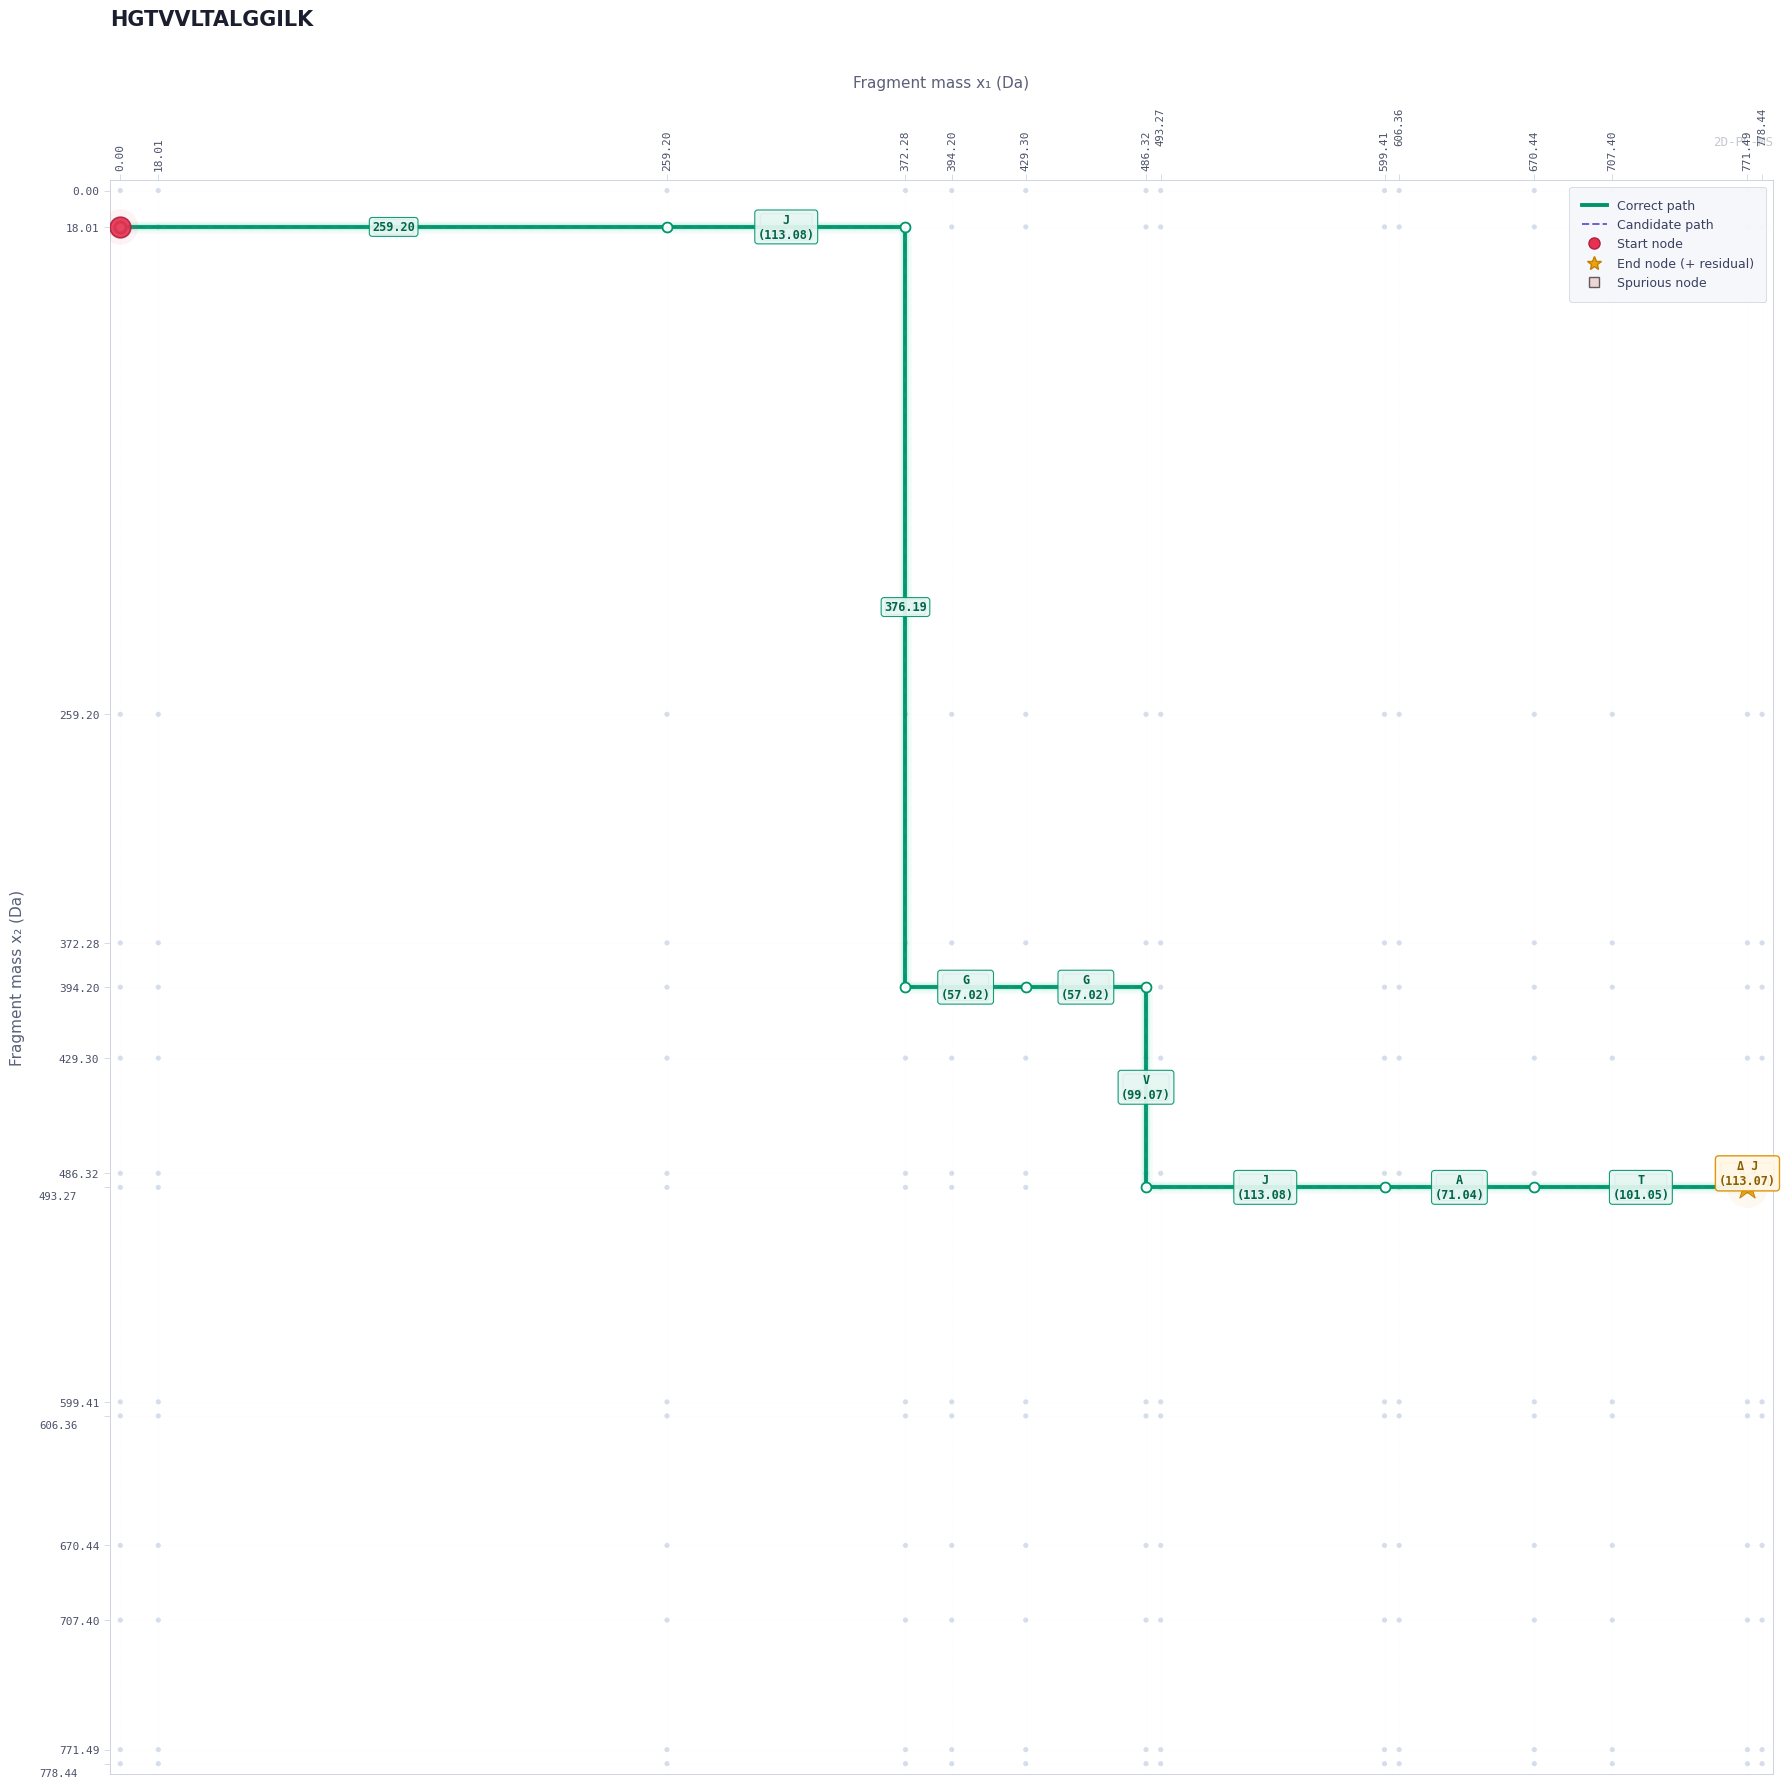

In [35]:
if __name__ =='__main__':
    
    allowed_mass_list = list(AA_MASSES.values()) + list(DOUBLE_AA_MASSES.values()) + list(TRIPLE_AA_MASSES.values()) + list(QUADRA_AA_MASSES.values())
    
    #pep_seq = 'HADGSFSDEMNTILDNLAARDFINWLIQTKITD'
    pep_seq = 'HGTVVLTALGGILK'
    charge = 3

    pep = peptide.Pep(f'[{pep_seq}+{charge}H]{charge}+', end_h20=True)
    #breaks = [i for i in range(1, len(pep_seq))]
    #breaks = [2, 7, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]
    breaks = [4, 5, 6, 7, 8, 9, 10, 11, 12]

    spec = [pep.ion_mass(f'b{i}') for i in breaks] + [pep.ion_mass(f'y{len(pep_seq) - i}') for i in breaks]
    spec = [i-1 for i in spec]
    spec = [0] + [18.01056] + spec + [pep.pep_mass]
    spec.sort()
    sorted_array = spec
    mid_point = len(sorted_array) // 2 + 4
    lower_half = sorted_array[:mid_point]
    upper_half = sorted_array[mid_point:]
    lower_half.sort()
    graph = construct_graph_nodes(lower_half)
    graph = build_adjacency_graph(nodes = graph, allowed_masses=allowed_mass_list, total_peptide_mass=pep.pep_mass - charge*1.007276, threshold=0.1)
    length, peptide_masses, node_path = find_longest_path(graph=graph, start_node=SOURCE_NODE)
    print(length)
    print(node_path)
    
    correct = node_path[:-1]
    candidates = [correct]
    
    amino_acid_masses_switch = {v: k for k, v in amino_acid_masses_merge.items()}
    
    visualize_all_paths(lower_half, spurious_masses=[938.464043*3-1, 953.522196-1], 
                         candidate_paths=candidates, 
                         correct_path=correct, 
                         aa_map=amino_acid_masses_switch,
                         title = pep_seq,
                         pep_mass=pep.seq_mass + 18.01056,
                         save_path= False)
    
    print()

10
[(0.0, 18.01056), (299.15536, 18.01056), (299.15536, 400.28704), (414.18229999999994, 400.28704), (414.18229999999994, 499.35544999999996), (527.26636, 499.35544999999996), (598.30347, 499.35544999999996), (598.30347, 598.38), (598.30347, 756.45662), (792.38384, 756.45662), 'Sink']


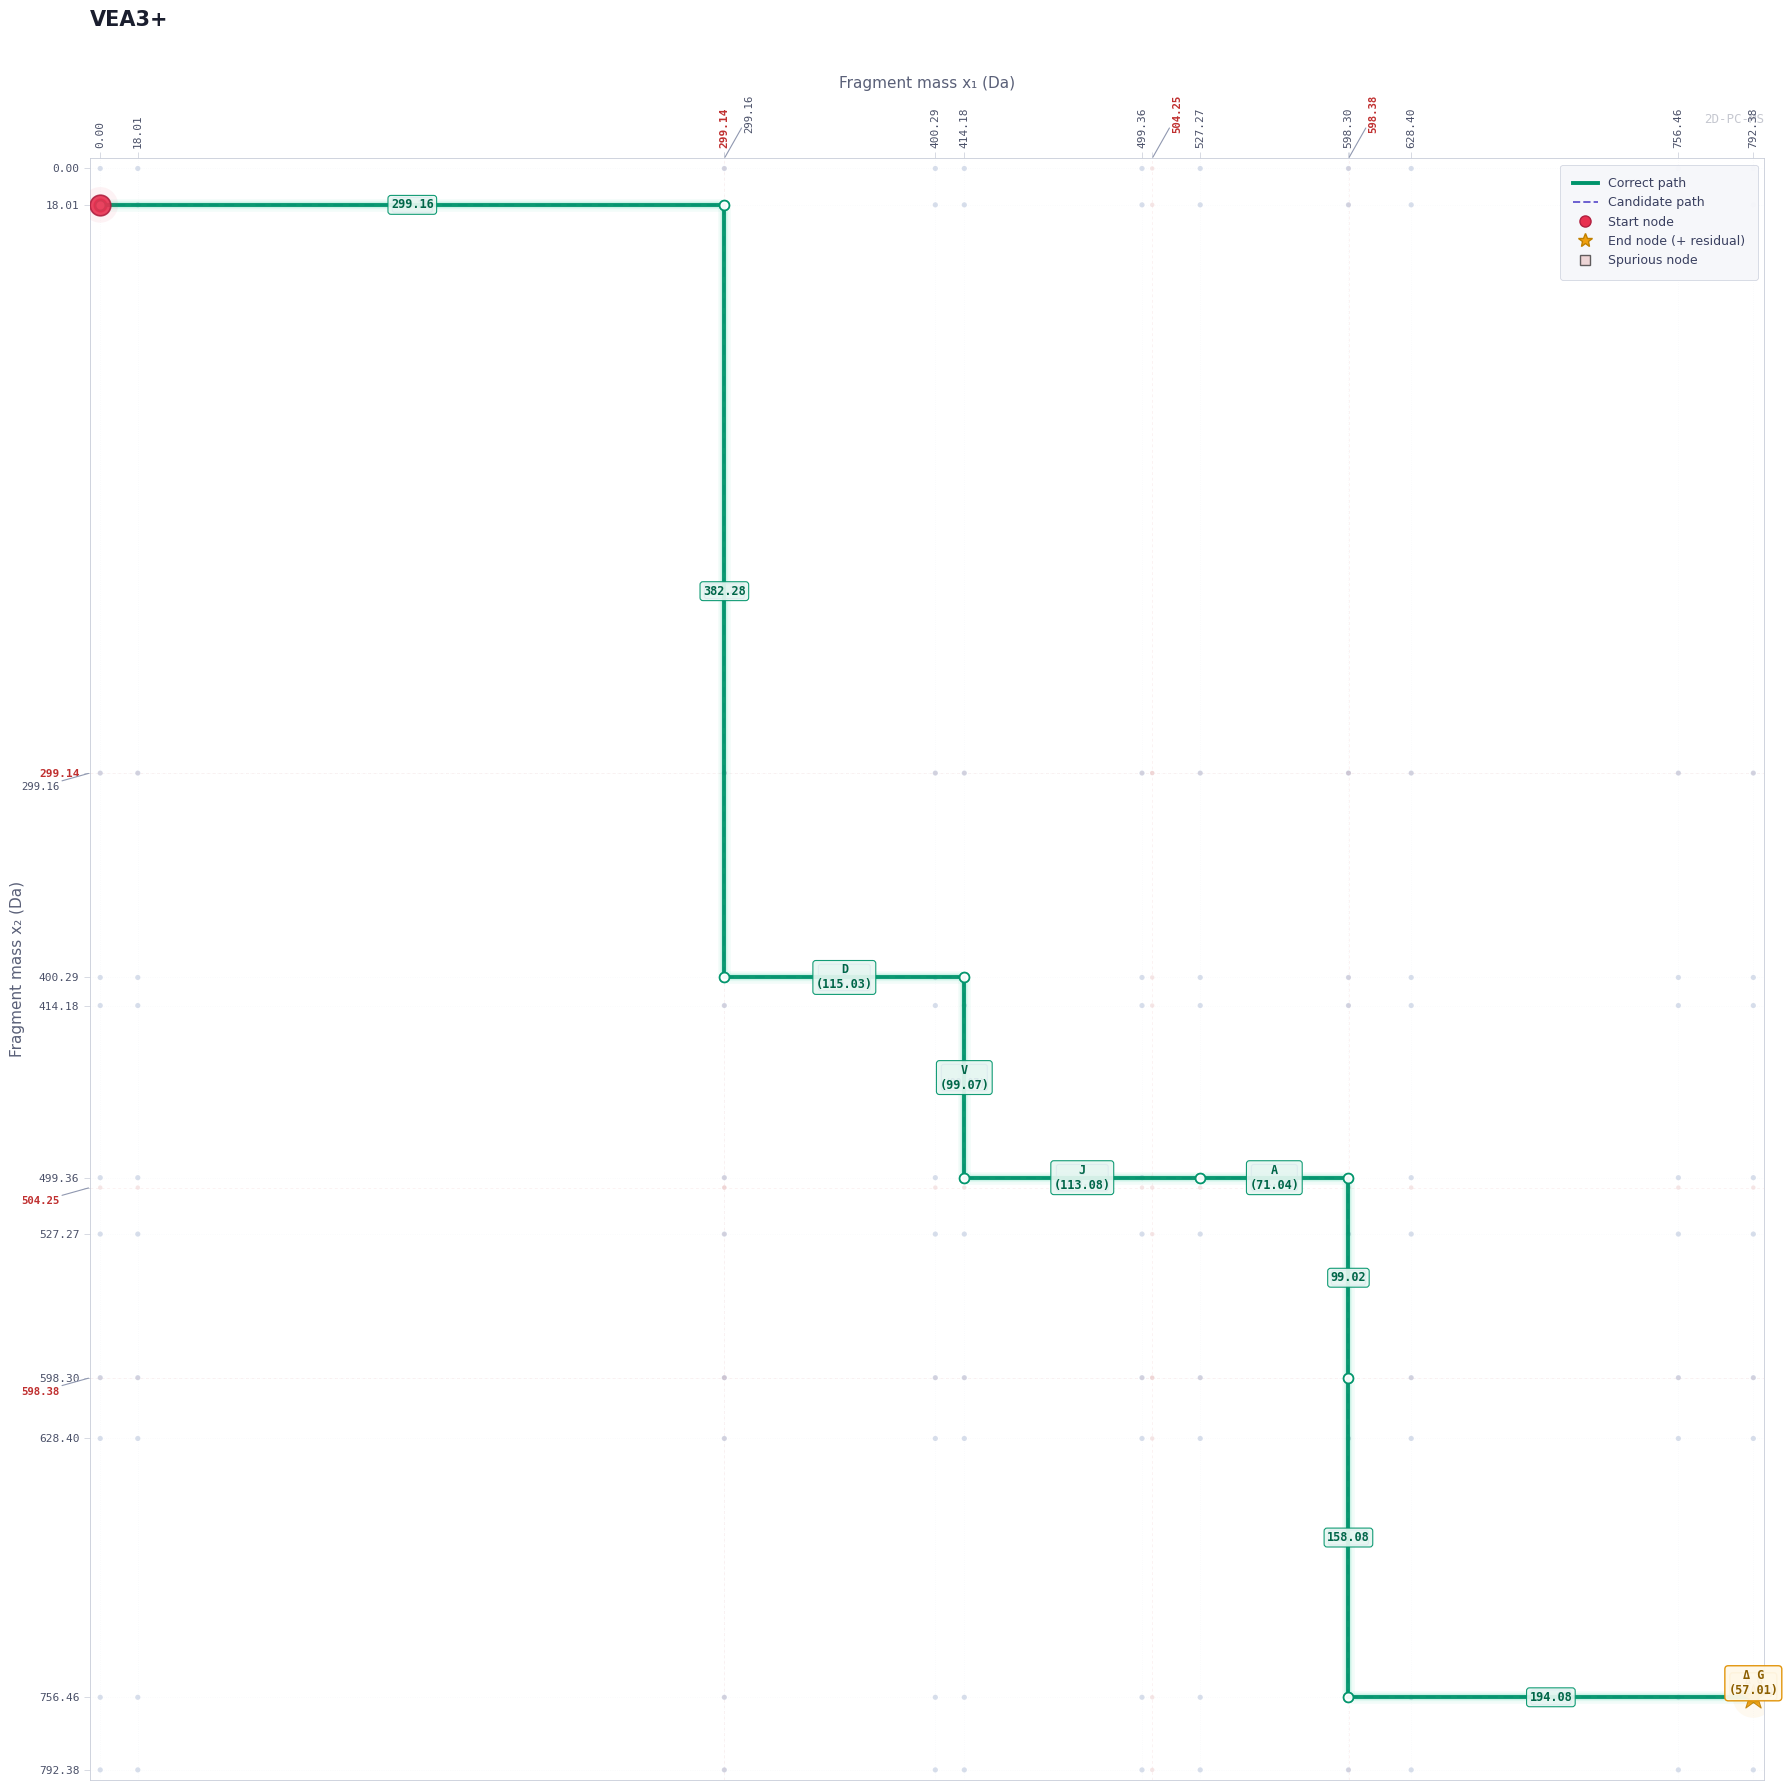

In [66]:
if __name__ =='__main__':
    
    allowed_mass_list = list(AA_MASSES.values()) + list(DOUBLE_AA_MASSES.values()) + list(TRIPLE_AA_MASSES.values()) + list(QUADRA_AA_MASSES.values())
    
    #pep_seq = 'HADGSFSDEMNTILDNLAARDFINWLIQTKITD'
    pep_seq = 'VEADIAGHGQEVLIR'
    charge = 3

    pep = peptide.Pep(f'[{pep_seq}+{charge}H]{charge}+', end_h20=True)
    #breaks = [i for i in range(1, len(pep_seq))]
    #breaks = [2, 7, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]
    breaks = [3, 4, 5, 6, 8, 9, 10, 11, 12]
    
    spurious = [299.14, 504.25, 598.38]

    spec = [pep.ion_mass(f'b{i}') for i in breaks] + [pep.ion_mass(f'y{len(pep_seq) - i}') for i in breaks]
    spec = [i-1 for i in spec]
    spec = [0] + [18.01056] + spec + [pep.pep_mass] + spurious
    spec.sort()
    sorted_array = spec
    mid_point = len(sorted_array) // 2 + 2
    lower_half = sorted_array[:mid_point]
    upper_half = sorted_array[mid_point:]
    lower_half.sort()
    graph = construct_graph_nodes(lower_half)
    graph = build_adjacency_graph(nodes = graph, allowed_masses=allowed_mass_list, total_peptide_mass=pep.pep_mass - charge*1.007276, threshold=0.05)
    length, peptide_masses, node_path = find_longest_path(graph=graph, start_node=SOURCE_NODE)
    print(length)
    print(node_path)
    
    correct = node_path[:-1]
    candidates = [correct]
    
    amino_acid_masses_switch = {v: k for k, v in amino_acid_masses_merge.items()}
    
    visualize_all_paths(lower_half, spurious_masses=spurious, 
                         candidate_paths=candidates, 
                         correct_path=correct, 
                         aa_map=amino_acid_masses_switch,
                         title = "VEA3+",
                         pep_mass=pep.seq_mass + 18.01056,
                         save_path= False)
    
    print()

26
[(0.0, 18.01056), (208.10327, 18.01056), (208.10327, 234.09242999999998), (208.10327, 347.17649), (208.10327, 475.27145), (208.10327, 576.3191300000001), (701.28414, 576.3191300000001), (701.28414, 704.3777100000001), (701.28414, 817.4617700000001), (701.28414, 930.5458300000001), (945.35367, 930.5458300000001), (1076.39416, 930.5458300000001), (1076.39416, 1116.62514), (1190.4370900000001, 1116.62514), (1190.4370900000001, 1230.6680700000002), (1291.48477, 1230.6680700000002), (1291.48477, 1343.75213), (1404.56883, 1343.75213), (1404.56883, 1490.8205400000002), (1517.6528899999998, 1490.8205400000002), (1517.6528899999998, 1605.8474800000001), (1632.6798299999998, 1605.8474800000001), (1746.7227599999999, 1605.8474800000001), (1746.7227599999999, 1761.9485900000002), (1746.7227599999999, 1832.9857000000002), (1746.7227599999999, 1904.0228100000002), 'Sink']


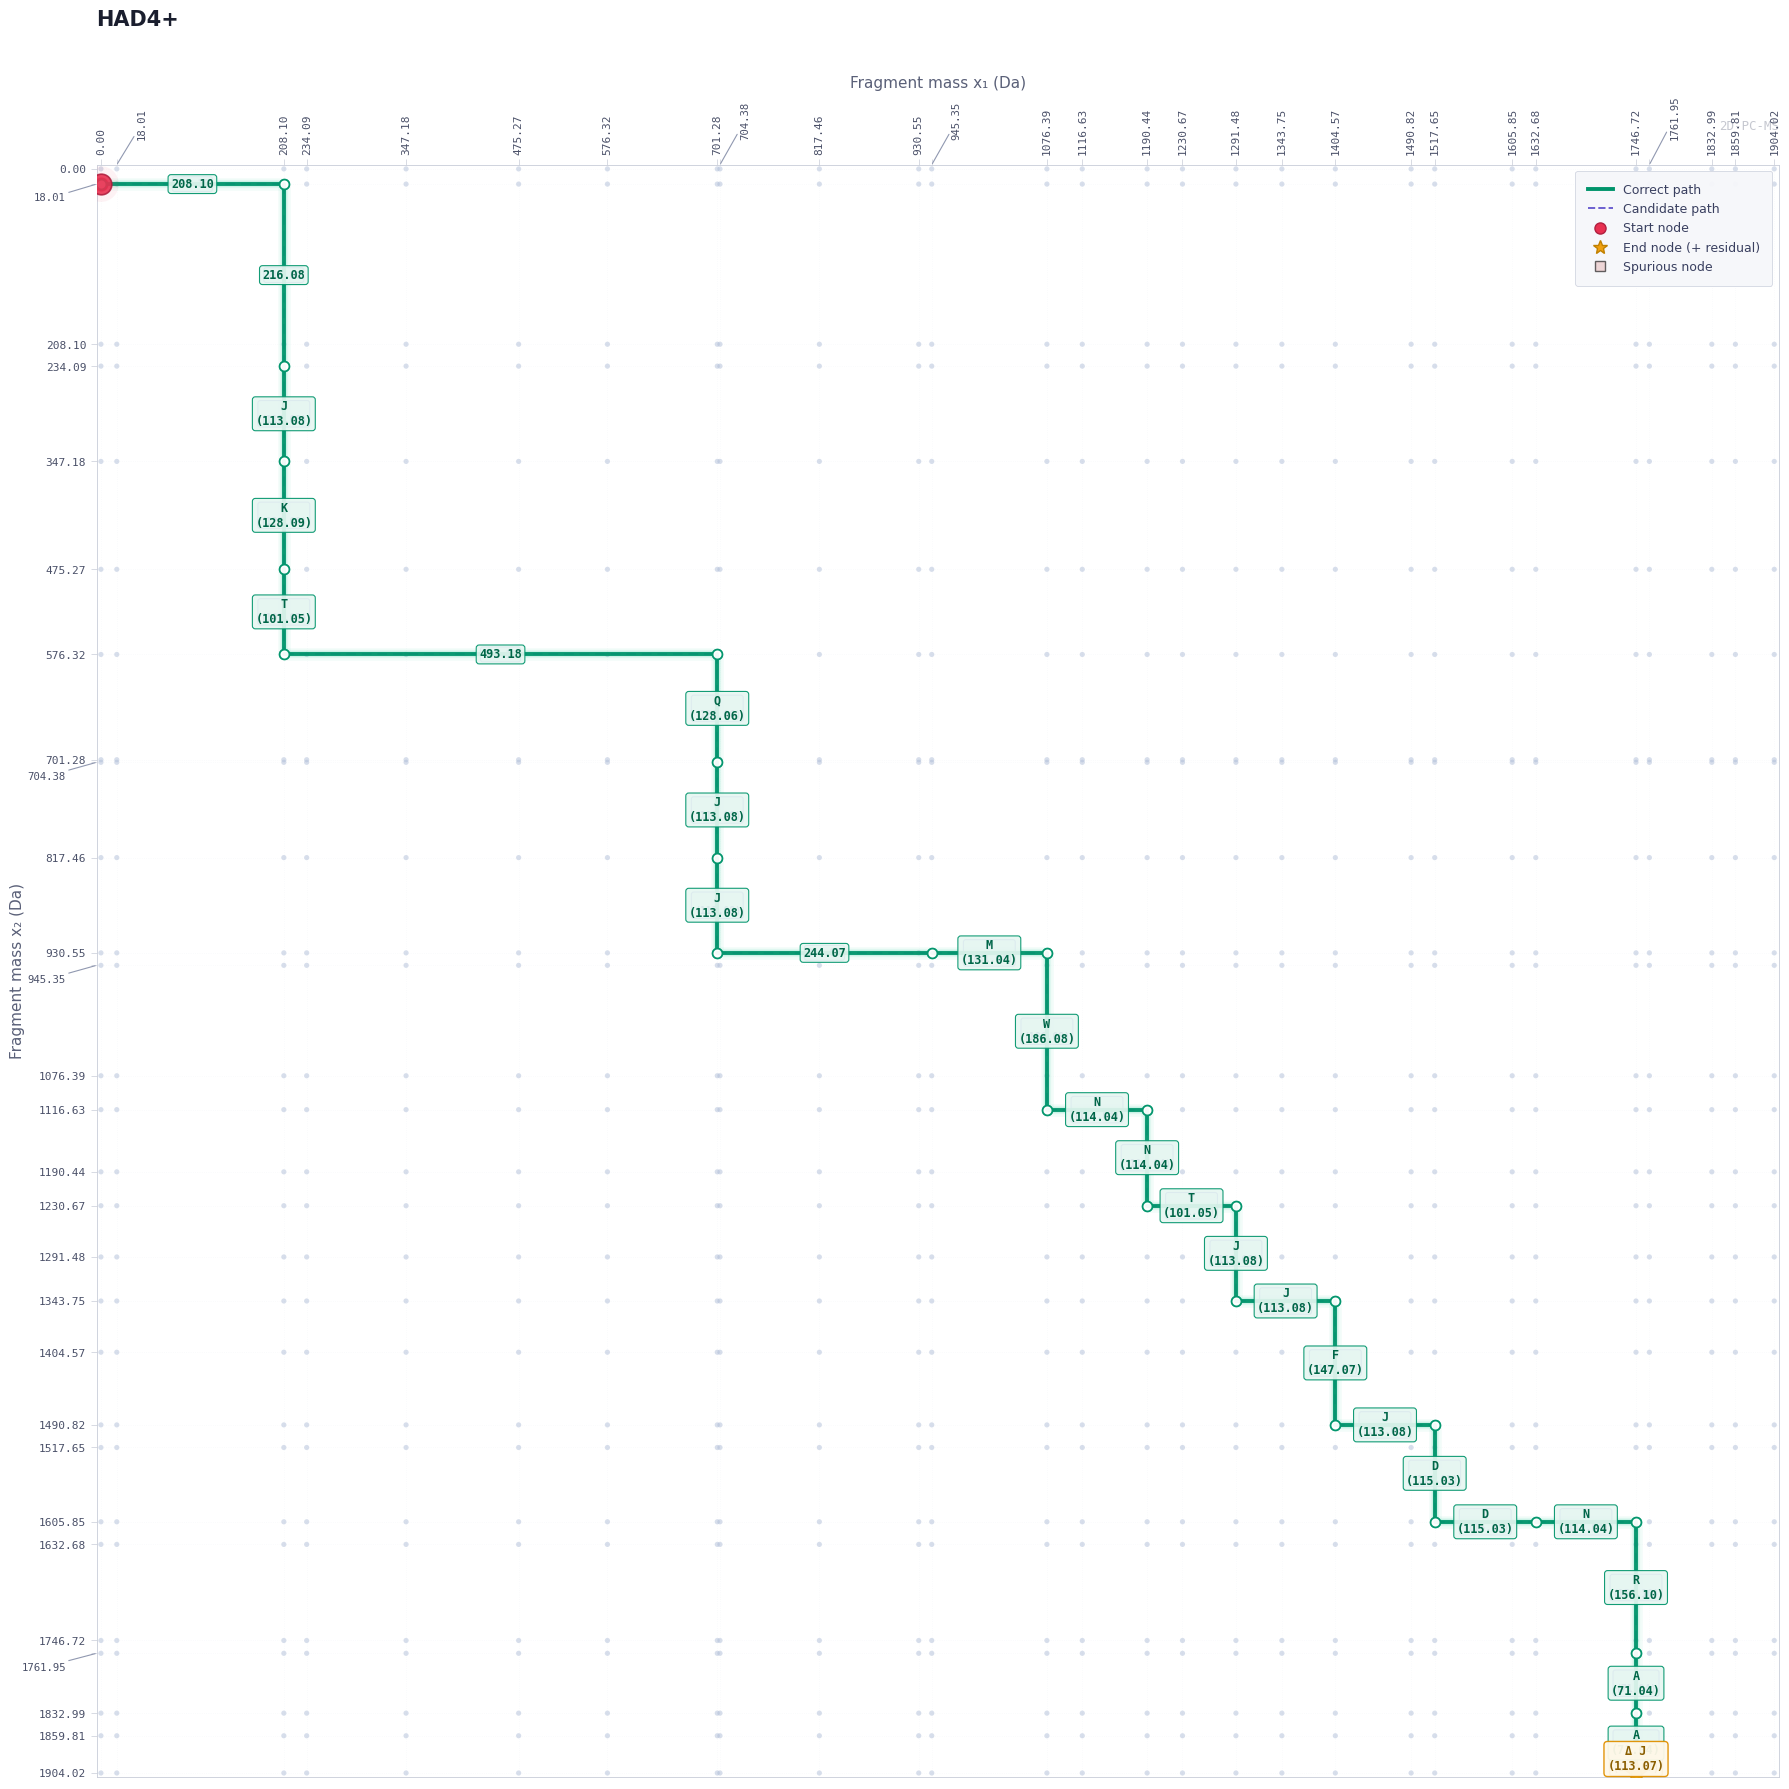

In [74]:
if __name__ =='__main__':
    
    allowed_mass_list = list(AA_MASSES.values()) + list(DOUBLE_AA_MASSES.values()) + list(TRIPLE_AA_MASSES.values()) + list(QUADRA_AA_MASSES.values())
    
    pep_seq = 'HADGSFSDEMNTILDNLAARDFINWLIQTKITD'
    #pep_seq = 'VEADIAGHGQEVLIR'
    charge = 3

    pep = peptide.Pep(f'[{pep_seq}+{charge}H]{charge}+', end_h20=True)
    #breaks = [i for i in range(1, len(pep_seq))]
    breaks = [2, 7, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]
    #breaks = [3, 4, 5, 6, 8, 9, 10, 11, 12]
    
    spurious = []

    spec = [pep.ion_mass(f'b{i}') for i in breaks] + [pep.ion_mass(f'y{len(pep_seq) - i}') for i in breaks]
    spec = [i-1 for i in spec]
    spec = [0] + [18.01056] + spec + [pep.pep_mass] + spurious
    spec.sort()
    sorted_array = spec
    mid_point = len(sorted_array) // 2 + 2
    lower_half = sorted_array[:mid_point]
    upper_half = sorted_array[mid_point:]
    lower_half.sort()
    graph = construct_graph_nodes(lower_half)
    graph = build_adjacency_graph(nodes = graph, allowed_masses=allowed_mass_list, total_peptide_mass=pep.pep_mass - charge*1.007276, threshold=0.05)
    length, peptide_masses, node_path = find_longest_path(graph=graph, start_node=SOURCE_NODE)
    print(length)
    print(node_path)
    
    correct = node_path[:-1]
    candidates = [correct]
    
    amino_acid_masses_switch = {v: k for k, v in amino_acid_masses_merge.items()}
    
    visualize_all_paths(lower_half, spurious_masses=spurious, 
                         candidate_paths=candidates, 
                         correct_path=correct, 
                         aa_map=amino_acid_masses_switch,
                         title = "HAD4+",
                         pep_mass=pep.seq_mass + 18.01056,
                         save_path= False)
    
    print()